# Data & Recovery

**Perishable Demand Forecasting & Zero-Waste Inventory Engine** — FreshRetailNet-50K.

All the real logic lives in `src/`. This notebook just calls it, in order, and shows what comes out.

| Step | What happens |
|---|---|
| 1 | load the data (rebuilds the subset only if it's missing) |
| 2 | baselines on recorded sales — the number every later model has to beat |
| 3 | compare a few recovery models and pick one |
| 4 | run the winner and save the recovered demand |
| 5 | sanity checks — did recovery behave, and did anything leak |

The one fact this whole notebook is built around: **a shelf that's sold out records zero sales, not zero demand.** The till under-counts on exactly the days a product is selling best. Train a forecaster on that raw number and it learns to keep ordering too little — and the shelf keeps emptying.

Everything below works at the **daily** level. The dataset also records which *hours* each shelf was empty, and that's what makes recovery possible at all — but that detail is handled inside `src/recovery.py` and never needs to surface here.

## 0. Setup

In [13]:
import sys
sys.path.insert(0, "..")   # notebooks/ is one level down, so the repo root has to go on the path

import warnings
warnings.filterwarnings('ignore')   # keeps sklearn/statsmodels convergence warnings out of the output

import json

import pandas as pd

from src.utils import config, data_io, plots     # paths, data loading, and plotting helpers
from src import baselines, recovery, splits       # the actual modelling code this notebook drives


def saved(path, flag):
    """Read a saved table, or name the flag that regenerates it."""
    if not path.exists():
        raise FileNotFoundError(f"{path.name} not found - set {flag} = True and re-run that cell")
    return pd.read_csv(path, index_col=0)

## 1. Data

A **series** is one `(store_id, product_id)` pair — one product in one store, tracked day by day.

`N_STORES` stores are drawn at random (seed `config.SUBSET_SEED`, frozen) and every series they carry comes with them, across all categories. We draw whole stores rather than individual series for two reasons:

- **It stays representative.** Nothing is picked on sales volume, so the subset matches the corpus on units/day and on how often shelves go empty.
- **Baskets stay complete.** Each store keeps its full assortment, which the ordering stage needs to plan across a real shelf, not just a few cherry-picked products.

The draw is also **nested**: the stores are one fixed shuffle, and we just take the first `N_STORES` of it. So growing the sample only adds stores — it never swaps out the ones already in there. That's what lets us say "the estimate settled as the sample grew" and mean it, rather than it just being a fluke of which stores got picked.

The parquet files are gitignored and rebuild automatically from `N_STORES` + the seed, so the cell below only builds them if they're missing. Whatever the subset ends up being gets written out to `outputs/subset_summary.md`, which is committed and rewritten on every rebuild — so that description can never drift out of sync with the data it's describing.

Only set `REBUILD = True` if you actually want to redraw from Hugging Face. **Everything downstream has to be regenerated after that.**

In [14]:
N_STORES = 100
REBUILD  = False   # True re-downloads and redraws the subset - OVERWRITES data/processed/

# Only build the subset if it isn't already sitting on disk (or a rebuild was explicitly asked for).
if REBUILD or not config.DAILY_TRAIN.exists():
    data_io.build_subset(n_stores=N_STORES)

daily = recovery.load_daily()   # daily frame + lag/rolling context + frozen period labels

# Quick sanity print: total rows, and how many distinct calendar days landed in each split.
print(f"{len(daily):,} rows | days per period:",
      daily[daily.split == "train"].groupby("period")["dt"].nunique().to_dict())

loading daily subset from data/processed
543,297 rows | days per period: {'calibration': 14, 'training': 62, 'validation': 14}


In [15]:
from IPython.display import Markdown

# data_io.build_subset rewrites this file every time it runs, so it always describes whatever
# subset is actually on disk right now - never a stale description of an older draw.
display(Markdown(config.SUBSET_SUMMARY.read_text(encoding="utf-8")))

# Working subset

*Rebuilt 2026-08-15T12:00:46 by `data_io.build_subset`. Regenerated on every rebuild - do not edit by hand.*

Seeded random sample of **100 of 898 stores** (seed 123), keeping every series they carry, all categories.

| | corpus | subset |
|---|---|---|
| series | 50,000 | 5,601 |
| stores | 898 | 100 |
| categories | 32 | 30 |
| products | 865 | 557 |
| train rows | 4,500,000 | 504,090 |
| units/day | 0.9986 | 0.997 |
| censored days | 44.3% | 43.8% |

The subset is **11.2% of the corpus** at ~56 series per store. Matching the corpus on
units/day and censored-day share is what makes it representative: nothing is selected on sales
volume, so no scope restriction has to be declared.

A further **39,207 rows** of shipped eval data are held back for the final evaluation and are
not read by any earlier stage.

Categories present: 0, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31

Store IDs: 10, 13, 19, 26, 36, 54, 56, 76, 78, 80, 91, 101, 106, 113, 119, 129, 142, 147, 176, 181, 187, 191, 192, 225, 234, 235, 255, 284, 293, 294, 299, 300, 307, 312, 318, 323, 327, 337, 343, 358, 362, 365, 368, 397, 398, 410, 413, 416, 423, 440, 447, 463, 466, 472, 487, 504, 515, 520, 522, 524, 526, 527, 539, 542, 547, 562, 587, 588, 597, 606, 611, 618, 622, 627, 628, 651, 669, 672, 677, 679, 685, 688, 706, 724, 725, 747, 752, 758, 776, 787, 806, 809, 826, 846, 850, 855, 862, 873, 892, 897


## 2. Baselines on recorded sales

Fitted on **training** days, scored on **non-stockout validation** days — that's the dataset's own convention, not something we chose. Both windows come straight out of the train file, cut by the dates in `config`.

The shipped eval file is the **test week**, and it's not touched here at all — it only gets opened once, at the very end.

Keep an eye on **WPE**: a negative number means the model is systematically under-forecasting, which is exactly the censoring bias the recovery layer exists to fix.

In [16]:
RUN_BASELINES = False   # off = load the saved CSV

# Either fit all three baselines fresh (seasonal-naive, SARIMA, XGBoost-quantile), or just
# read back the scorecard from the last time this was run.
board = (baselines.build_scorecard(daily) if RUN_BASELINES
         else saved(config.BASELINE_SCORECARD, "RUN_BASELINES"))
board.round(4)

,WAPE,WPE,MAE,pinball@0.5,pinball(avg),CRPS~,n_series,n_failed
seasonal_naive,0.4213,0.0187,0.4301,0.2212,NaN,NaN,NaN,NaN
xgboost_quantile,0.3423,-0.0187,0.3502,NaN,0.1121,0.2181,NaN,NaN
sarima,0.5210,-0.2521,0.4149,NaN,NaN,NaN,30.0,0.0


**Result.** XGBoost-quantile is the number every later stage has to beat. A `WPE` close to zero here does *not* mean censoring is harmless — these rows are all non-stockout days, exactly the days censoring never touches. The scorecard simply can't see the problem from here, which is why the real evidence for recovery shows up further down, not in this table.

`sarima` is fitted on a sample of series rather than all of them, so treat it as a classical-statistics reference point, not a fair competitor.

## 3. Which recovery model?

### How recovery is trained and tested

A real stockout has no ground truth — that's the whole problem, so there's no ready-made test set for this. We build one instead, out of the days we can actually trust:

| | |
|---|---|
| **Training data** | hours the shelf was **stocked**, in the training period — the only hours where what sold is what was actually wanted |
| **Test data** | days the shelf was **full all day**. The recorded total on those days *is* the true demand, so they can be used as answer keys |
| **The test itself** | hold those full-shelf days out of training, pretend they were stocked out 06:00–22:00, recover them, and compare the recovered total against the real one we hid |

Because the test days are held out of training, the model is being scored on days it has genuinely never seen — same discipline as any train/test split.

### The bias correction

Stage 1 predicts **one hour at a time**, and per hour it's close to unbiased. But a censored day needs **16 hours summed up**, and those small errors don't cancel out — they add up, and the total comes out systematically **too high**. So we fit one multiplier: `bias_correction = true total / recovered total`.

It's fitted on **half** the held-out days and scored on the other half, so the error we report is never measured on the same days the correction was tuned on. Every recovered hour gets multiplied by it.

Without that correction, every recovered day would be overstated — and you'd end up ordering too much on exactly the days the model was supposed to help with. `wpe_uncorrected` in the table below shows how big that error was before the fix; `bias_correction` is the multiplier that removes it.

### The candidates

| candidate | what it is |
|---|---|
| `lightgbm_tweedie` | LightGBM, Tweedie loss |
| `lightgbm_poisson` | LightGBM, Poisson loss |
| `lightgbm_l2` | LightGBM, ordinary squared-error loss |
| `xgboost` | the other gradient-boosting library, squared error |
| `poisson_glm` | a plain Poisson regression, no trees |
| `series_hour_mean` | no model at all — just that series' historical average |

`series_hour_mean` is the control: if a model can't beat a lookup table, it isn't earning its complexity. The *loss function* matters here as much as the library — squared error fits the conditional **median**, which for a mostly-zero target is often just zero, while Tweedie and Poisson fit the conditional **mean**, which is what a daily total actually needs.

### How to pick a row

1. **`wape` decides. Lowest wins.** It's the error as a share of actual demand.
2. **Make sure it clearly beats `series_hour_mean`.** If the margin is thin, prefer the simpler model.
3. **Keep `wpe` within about ±0.02.** Positive means over-predicting (waste), negative means under-predicting (stockouts). A model that's accurate but skewed one way ends up wrong in the same direction every single day.
4. **Only break ties on `fit_seconds`** if two rows are within about 1% of each other on `wape`.

Treat any gap under 1–2% as noise — just changing which stores are in the subset moves `wape` by more than that, so a hair's-breadth winner isn't really a winner.

`bias_correction` and `wpe_uncorrected` are **diagnostics, not selection criteria**. Each candidate fits its own correction, so those numbers don't make the candidates comparable on their own.

In [17]:
RUN_COMPARISON = False 

# Fit and score all six recovery candidates on the held-out full-shelf days (see the markdown
# above for how that test is built), or just load the ranking from the last run.
comparison = (recovery.compare_models(daily) if RUN_COMPARISON
              else saved(config.RECOVERY_COMPARISON, "RUN_COMPARISON"))
comparison

,n_test_days,bias_correction,wpe_uncorrected,fit_seconds,wape,mae,wpe
lightgbm_tweedie,2500.0,0.9001,0.1316,163.2,0.2966,0.2680,0.0186
xgboost,2500.0,0.8877,0.1411,202.5,0.3009,0.2719,0.0130
lightgbm_poisson,2500.0,0.8858,0.1485,173.1,0.3051,0.2757,0.0174
lightgbm_l2,2500.0,0.8852,0.1465,137.2,0.3057,0.2763,0.0149
series_hour_mean,2500.0,0.8753,0.1301,13.6,0.3684,0.3329,-0.0109
poisson_glm,2500.0,1.0285,-0.0034,70.0,0.5692,0.5144,0.0250


**Result.** `lightgbm_tweedie` has the lowest `wape` and beats the no-model control by roughly a fifth — that's what justifies using a model here instead of a lookup table. Its `wpe` also sits inside the ±0.02 band, so it isn't quietly ordering high or low.

`poisson_glm` is the interesting failure case: the smallest aggregation bias of any candidate, paired with by far the worst accuracy. Unbiased and inaccurate at the same time. That's why `wape` is what decides and bias is only a gate — a model can be perfectly centred on average and still be wrong every single day.

## 4. Run the chosen model

Type the winning row name into the cell below. This fits Stage 1 on **every** stocked training hour (not the reduced set the comparison test used), fills in the stocked-out hours, applies that model's bias correction, and saves three things:

- `outputs/models/` — the fitted model itself
- `outputs/recovery_params.json` — which model was used, and what correction was applied
- `data/processed/*_recovered.parquet` — the daily frame with `recovered_demand` added on

Without those files on disk, `recovered_demand` is just a column nobody could explain or reproduce.

In [18]:
MODEL        = "lightgbm_tweedie"   # a row name from the table above
RUN_RECOVERY = False                # off = load the saved recovered parquets

if RUN_RECOVERY:
    # Fit the chosen model on every stocked training hour, fill in the stocked-out hours,
    # apply the bias correction, and write the recovered parquets + params to disk.
    recovered = recovery.run(daily, MODEL)
else:
    # Otherwise just attach the already-saved recovered_demand column onto the daily frame.
    if not config.RECOVERED_TRAIN.exists():
        raise FileNotFoundError(f"{config.RECOVERED_TRAIN.name} not found - "
                                "set RUN_RECOVERY = True and re-run this cell")
    recovered = daily.merge(
        data_io.load("recovered")[["store_id", "product_id", "dt", "recovered_demand"]],
        on=["store_id", "product_id", "dt"], how="left")
    print("loaded saved recovery |", recovery.load_params())

recovered[["dt", "store_id", "product_id", "sale_amount", "recovered_demand", "is_censored"]].head(3)

loading recovered subset from data/processed
loaded saved recovery | {'model': 'lightgbm_tweedie', 'n_test_days': 2500, 'bias_correction': 0.9001, 'wpe_uncorrected': 0.1316, 'fit_seconds': 141.1, 'wape': 0.2966, 'mae': 0.268, 'wpe': 0.0186}


,dt,store_id,product_id,sale_amount,recovered_demand,is_censored
0,2024-03-28,10,4,0.8,0.948001,1
1,2024-03-29,10,4,0.9,0.973271,1
2,2024-03-30,10,4,2.4,2.400000,0


## 5. Did recovery behave?

Filling in hidden demand will always push the totals up, so "the numbers went up" on its own proves nothing. Two real checks follow, and only the second one is actually capable of failing.

**Did the demand land where it should?** It should show up on hours that were lost to a stockout, and nowhere else. The table below compares that against a control that just fills every stocked-out hour with one flat number — no model, no features. If the control climbs just as much, the climb is pure arithmetic and says nothing about whether the model is any good. The column that actually means something is `model_vs_flat_%`: below 100 means the model is adding *less* than the naive filler would, i.e. it's the more conservative of the two.

**Does the correction still hold up weeks later?** We fit one multiplier inside the training window and then apply it all the way out to the test week. If that multiplier had drifted, every later day would be tilted a little more than the last — and since `recovered_demand` is what the forecaster actually trains on, that tilt would quietly work its way into everything downstream.

In [19]:
# Where did the extra demand land, and is the model more conservative than a naive flat fill?
bucket = recovery.bias_by_censoring(recovered)
bucket.round(2).to_csv(config.BIAS_BUCKET_CSV)
display(bucket.round(2))

# How much demand did the till miss overall, and specifically on the days a shelf emptied?
hidden = recovery.how_much_was_hidden(recovered)
print(f"Across the whole subset the till under-recorded demand by "
      f"{hidden['under_recorded_all_days_pct']}%,")
print(f"and by {hidden['under_recorded_censored_days_pct']}% on the "
      f"{hidden['censored_day_share_pct']}% of days a shelf actually emptied.")

,days,recorded_mean,recovered_mean,uplift_%,uplift_%_flat_fill,model_vs_flat_%
censoring_band,,,,,,
low (0-25%),71589.0,1.41,1.52,7.98,14.75,54.10
med (25-50%),83405.0,1.16,1.49,28.75,42.10,68.29
high (50-75%),48999.0,0.83,1.40,69.52,99.31,70.00
severe (75-100%),32587.0,0.21,1.17,445.84,556.23,80.15


Across the whole subset the till under-recorded demand by 17.3%,
and by 38.8% on the 43.5% of days a shelf actually emptied.


**Result.** The uplift climbs steeply as censoring gets worse — but so does the flat fill, so that climb is just arithmetic (more missing hours filled in, on a smaller base) and can't by itself tell a good filler from a bad one. What the table does establish is `model_vs_flat_%`: the model adds **less than the naive filler in every band**, so it isn't inventing demand out of nowhere.

Worth reading `recorded_mean` down the column too. The raw data makes it look like the most-stocked-out products barely sell at all — which is the censoring bias itself, sitting right there in one column.

### The same effect on one series

The tables above are aggregates. This plot shows the mechanism on a single series instead — the **most-censored one in the whole subset**, picked because that's where the gap is big enough to actually see.

Three things worth noticing:

- **Outside the grey bands, the two lines sit right on top of each other.** Recovery only touches stocked-out hours and nothing else, so on a full-shelf day `recovered_demand` and `sale_amount` are literally the same number by construction.
- **Inside the grey bands, the recovered line lifts away from recorded sales.** That gap is the demand the till never saw — the exact thing this whole stage is trying to estimate.
- **Recorded sales never sit above recovered demand.** Every recovered hour is floored at what actually sold, so the recovered total can only ever match or exceed the recorded one. That's enforced directly in `recovery.run`, not just something we hope holds.

One series proves nothing on its own — the real evidence is in the tables above. This is just here to make the mechanism concrete before we get to the checks that could have actually falsified it.

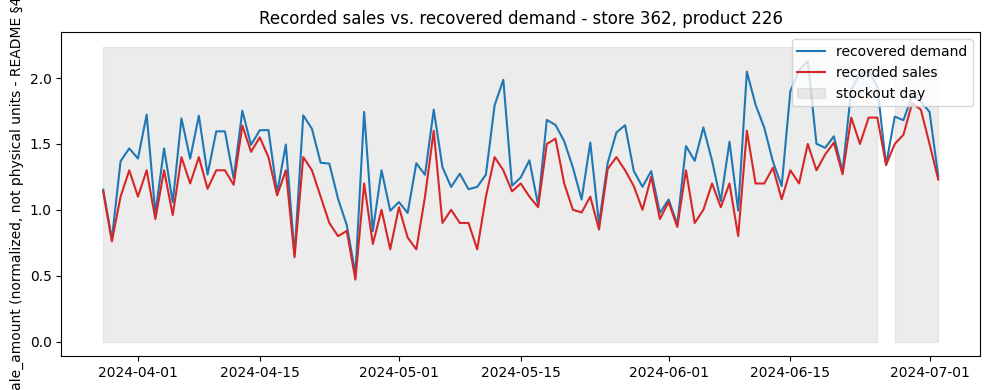

In [20]:
# Draw the recovered-vs-recorded lines for the single most-censored series in the subset.
plots.plot_recovery_example(recovered, save_path=config.RECOVERY_PLOT)

### Does one multiplier still hold weeks later?

`bias_correction` is a single number, fitted on full-shelf days inside the training window and then applied to every recovered hour all the way out to the test week. Since `recovered_demand` is what the forecaster trains on, a correction that drifts would tilt the target more and more the later the day is — and every score downstream would inherit that tilt while still looking perfectly clean.

So we refit it separately in each window. Full-shelf days only, all held out of the fit, so the calendar is the only thing that's actually changing between rows.

In [21]:
RUN_CORRECTION_CHECK = False   # refits Stage 1 per window; off = load the saved CSV

# Refit the bias-correction multiplier separately inside each calendar window, to check it
# isn't quietly drifting further out the later the forecast horizon gets.
(recovery.correction_by_period(daily) if RUN_CORRECTION_CHECK
 else saved(config.CORRECTION_BY_PERIOD, "RUN_CORRECTION_CHECK"))

,n_clean_days,correction,shipped_is_off_by_%
period,,,
training,5000.0,0.8919,0.9216
validation,5000.0,0.8574,4.9791
calibration,5000.0,0.9234,-2.5213


**Result.** The shipped correction stays close to the one refitted inside each window, and the deviation doesn't move in one direction — one window sits above it, another below. It wobbles, it doesn't drift. So a single multiplier is fine as-is and doesn't need per-period patching.

This mattered because `recovered_demand` is what the forecaster trains on: a correction that drifted with the calendar would tilt the training target more the later the day, and every downstream score would inherit that tilt while still looking clean. This is a check that could have failed, and didn't.

### Did anything leak?

Five mechanical checks, run on the exact same frames the pipeline actually fitted on — so if a bug ever creeps into the training-pool filter, this is where it gets caught.

In [22]:
RUN_LEAKAGE = False   # rebuilds the hourly frame; off = load the saved verdicts

if RUN_LEAKAGE:
    # Run the five mechanical leakage checks fresh and save the verdicts.
    checks = splits.check_leakage(daily)
    config.LEAKAGE_CHECKS.write_text(json.dumps(checks, indent=2))
else:
    # Otherwise just read back the verdicts from the last time this ran.
    checks = json.loads(config.LEAKAGE_CHECKS.read_text())
    print(f"loaded saved verdicts: {sum(checks.values())}/{len(checks)} passed")

# Stop here rather than silently letting a leakage failure pass unnoticed.
assert all(checks.values()), "leakage check failed - fix before trusting anything above"

loaded saved verdicts: 5/5 passed


## 6. Does recovery change the forecast?

One model — the strongest baseline — trained twice with identical settings and seed: once on raw sales, once on recovered demand, each given the history it would genuinely have had. Both are scored the same way: per date, non-stockout validation rows only, against recorded `sale_amount`.

Read this **per band, never pooled**. On the rows we're scoring, the two targets are identical by construction, so pooled together the recovered version can only look worse — it's predicting real demand and gets marked down whenever that exceeds recorded sales. The real question is whether it removes the under-forecast on the products that keep selling out, and pooled numbers can hide that answer completely.

In [23]:
RUN_IMPACT = False   # off = load the saved CSV

# Train the strongest baseline twice - once on raw sales, once on recovered demand - and
# compare them split by how often each product sells out.
impact = (baselines.recovery_impact(recovered) if RUN_IMPACT
          else pd.read_csv(config.RECOVERY_IMPACT, index_col=0, header=[0, 1]))
impact.round(4)

xgb_raw                                               \
              n_scored    WAPE     WPE     MAE pinball(avg)   CRPS~   
<25% censored   3955.0  0.4712  0.0195  0.3407       0.1082  0.2967   
25-50%         30345.0  0.3601  0.0078  0.2953       0.0945  0.2294   
50-75%         12319.0  0.3084 -0.0151  0.4272       0.1361  0.1950   
>=75%           1375.0  0.2875 -0.1964  0.8947       0.2948  0.1915   
ALL            47994.0  0.3423 -0.0187  0.3502       0.1121  0.2181   

              xgb_recovered                                               \
                   n_scored    WAPE     WPE     MAE pinball(avg)   CRPS~   
<25% censored        3955.0  0.4604  0.1162  0.3330       0.1081  0.2964   
25-50%              30345.0  0.3702  0.1129  0.3038       0.0970  0.2353   
50-75%              12319.0  0.3124  0.1120  0.4349       0.1384  0.1983   
>=75%                1375.0  0.2256  0.0013  0.6984       0.2252  0.1463   
ALL                 47994.0  0.3426  0.1014  0.3512       0.1122  0.2183   

                 gap  
              WAPE_%  
<25% censored  -2.29  
25-50%          2.80  
50-75%          1.30  
>=75%         -21.53  
ALL             0.09

**Result.** On products that sell out 75%+ of the time, the raw-trained model badly under-forecasts — it learned from sales that never actually happened. The recovered version removes almost all of that bias and is **21.5% more accurate** on those same rows. That's measured against recorded sales, on days the shelf never emptied, so nothing about the recovery assumption sneaks into the scoring itself.

Pooled, the two look level. That's not a contradiction — it's the paragraph above playing out: the rows being scored are exactly the rows where the two targets agree, so the pooled number structurally can't show the effect either way. The price of recovery is a mild over-forecast on the less-censored bands, and that's what the ordering stage has to earn back.

The 75%+ band is also the smallest one in the table. The direction here is clean and matches the mechanism we'd expect, but treat the exact size of the improvement as indicative rather than precise.

## Appendix — why models are ranked on daily totals, not on hours

Stage 1 predicts one hour at a time, so scoring it per hour seems like the obvious thing to do. It doesn't work, and it's worth one table to show why, since it's the first thing anyone asks about this setup.

Most hours sell nothing at all. So a model that just predicts zero everywhere is right on almost every hour, and wrong by exactly the true amount on the rest — which scores **WAPE = 1.0000 exactly**, purely by construction. If real models can't clear that comfortably, the metric is basically rewarding *doing no recovery at all*, and it can't rank recovery models against each other.

Nothing downstream actually reads this table. It's here purely to justify the choice made back in step 3.

In [24]:
RUN_APPENDIX = False   # one fit per candidate; off = load the saved CSV

# Same candidates as step 3, scored per hour instead of per day - see the markdown above for
# why that turns out to be a much weaker test that can't actually rank the models.
hour_level = (recovery.hour_level_table(daily) if RUN_APPENDIX
              else saved(config.HOUR_LEVEL_TABLE, "RUN_APPENDIX"))
hour_level

,wape,mae,wpe,fit_seconds
lightgbm_tweedie,0.9880,0.051800,-0.0164,130.1
xgboost,0.9920,0.052000,0.0014,175.0
lightgbm_l2,0.9987,0.052300,0.0011,77.3
lightgbm_poisson,1.0032,0.052600,-0.0012,112.1
series_hour_mean,1.0180,0.053300,-0.0020,1.9
poisson_glm,1.3722,0.071900,-0.0024,42.5
all_zeros,1.0000,0.052391,-1.0000,0.0


**Result.** The do-nothing predictor scores exactly 1.0000, several of the real candidates score **worse** than that, and even the best one only clears it by about a percentage point. So on this metric, the entire distance between "the best model we have" and "predict nothing" is one percentage point — small enough that noise alone could reorder the table.

That's exactly why step 3 ranks candidates on daily totals instead, where aggregating removes most of those zeros and the comparison actually means something.